In [1]:
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


from pathlib import Path



BASE_DIR = Path(
    r"C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation"
)


DATA_DIR = BASE_DIR / "final_data"

RESULT_DIR = BASE_DIR / "results"



print("="*90)
print("ABLATION STUDY NOTEBOOK")
print("="*90)

print(BASE_DIR)

ABLATION STUDY NOTEBOOK
C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation


In [4]:
TABULAR_DIR = (
    DATA_DIR /
    "splits" /
    "tabular"
)


train_tabular = pd.read_csv(
    TABULAR_DIR / "train_tabular.csv"
)


val_tabular = pd.read_csv(
    TABULAR_DIR / "validation_tabular.csv"
)


test_tabular = pd.read_csv(
    TABULAR_DIR / "test_tabular.csv"
)



print("="*90)
print("TABULAR DATA")
print("="*90)


print(
    "Train:",
    train_tabular.shape
)


print(
    "Validation:",
    val_tabular.shape
)


print(
    "Test:",
    test_tabular.shape
)

TABULAR DATA
Train: (671, 43)
Validation: (144, 43)
Test: (144, 43)


In [6]:
EMB_DIR = (
    DATA_DIR /
    "embeddings" /
    "xlmr"
)



train_text_embeddings = np.load(
    EMB_DIR /
    "train_user_embeddings.npy"
)


val_text_embeddings = np.load(
    EMB_DIR /
    "val_user_embeddings.npy"
)


test_text_embeddings = np.load(
    EMB_DIR /
    "test_user_embeddings.npy"
)



train_text_keys = np.load(
    EMB_DIR /
    "train_user_keys.npy",
    allow_pickle=True
)


val_text_keys = np.load(
    EMB_DIR /
    "val_user_keys.npy",
    allow_pickle=True
)


test_text_keys = np.load(
    EMB_DIR /
    "test_user_keys.npy",
    allow_pickle=True
)



print("="*90)
print("TEXT EMBEDDINGS")
print("="*90)


print(
    "Train:",
    train_text_embeddings.shape
)


print(
    "Validation:",
    val_text_embeddings.shape
)


print(
    "Test:",
    test_text_embeddings.shape
)


print("\nSample keys:")
print(train_text_keys[:5])

TEXT EMBEDDINGS
Train: (671, 768)
Validation: (144, 768)
Test: (143, 768)

Sample keys:
[['007mi00']
 ['0mhp037']
 ['2002kingfox']
 ['2expvzwq7llpx4p']
 ['2tosgzcfj8vtsjk']]


In [7]:
GRAPH_DIR = (
    DATA_DIR /
    "graph"
)


graph_data = torch.load(
    GRAPH_DIR /
    "graph_data_degree_only.pt",
    weights_only=False
)



with open(
    GRAPH_DIR /
    "node_to_id.pkl",
    "rb"
) as f:

    import pickle

    node_to_id = pickle.load(f)



degree_features = np.load(
    GRAPH_DIR /
    "degree_features.npy"
)



print("="*90)
print("GRAPH DATA")
print("="*90)


print(graph_data)


print(
    "Degree features:",
    degree_features.shape
)


print(
    "Nodes:",
    len(node_to_id)
)

c:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation\env\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


GRAPH DATA
Data(x=[13466, 3], edge_index=[2, 569486], y=[13466], train_mask=[13466], val_mask=[13466], test_mask=[13466])
Degree features: (13466, 3)
Nodes: 13466


In [8]:
feature_cols = (
    train_tabular
    .select_dtypes(
        include=[
            "float64",
            "float32",
            "int64",
            "int32"
        ]
    )
    .columns
    .tolist()
)


feature_cols.remove(
    "label_binary"
)


if "graph_node_id" in feature_cols:
    feature_cols.remove(
        "graph_node_id"
    )


print("="*90)
print("TABULAR FEATURES")
print("="*90)

print(
    "Number of features:",
    len(feature_cols)
)

print(feature_cols)

TABULAR FEATURES
Number of features: 40
['followers_count', 'friends_count', 'favourites_count', 'listed_count', 'media_count', 'statuses_count', 'user_age', 'follower_growth_rate', 'friends_growth_rate', 'default_profile', 'default_profile_image', 'has_custom_timelines', 'possibly_sensitive', 'hashtag_in_description', 'numbers_in_description', 'no_type_tweet', 'no_type_retweet_with_comment', 'no_type_reply', 'mean_no_media_per_tweet', 'mean_no_words', 'no_languages', 'mean_no_hashtags', 'mean_favourites_per_tweet', 'time_between_tweets', 'tweet_frequency', 'min_tweets_per_hour', 'min_tweets_per_day', 'max_tweets_per_hour', 'max_tweets_per_day', 'max_occurence_of_same_gap', 'unique_mention_rate_per_tweet', 'mean_user_mentions_per_tweet', 'retweet_as_tweet_rate', 'no_retweet_tweets', 'mean_retweets_per_tweet', 'description_length', 'followers_friend_ratio', 'num_digits_in_name', 'num_digits_in_username', 'url_in_description']


In [9]:
from torch.utils.data import Dataset


class TabularTextDataset(Dataset):

    def __init__(
        self,
        tabular_df,
        text_embeddings,
        text_keys
    ):

        self.samples = []


        for i, row in tabular_df.iterrows():


            user_key = str(
                row["user_key"]
            ).lower()



            # find text embedding

            matches = np.where(
                text_keys.flatten()
                ==
                user_key
            )[0]


            if len(matches) == 0:
                continue


            text_idx = matches[0]



            tabular_values = (
                row[feature_cols]
                .astype(float)
                .values
            )



            self.samples.append(
                {

                    "tabular":
                    torch.tensor(
                        tabular_values,
                        dtype=torch.float32
                    ),


                    "text":
                    torch.tensor(
                        text_embeddings[text_idx],
                        dtype=torch.float32
                    ),


                    "label":
                    torch.tensor(
                        row["label_binary"],
                        dtype=torch.long
                    )

                }
            )



    def __len__(self):

        return len(self.samples)



    def __getitem__(
        self,
        idx
    ):

        return self.samples[idx]

In [10]:
train_dataset_tt = TabularTextDataset(
    train_tabular,
    train_text_embeddings,
    train_text_keys
)


val_dataset_tt = TabularTextDataset(
    val_tabular,
    val_text_embeddings,
    val_text_keys
)


test_dataset_tt = TabularTextDataset(
    test_tabular,
    test_text_embeddings,
    test_text_keys
)



print("="*90)
print("TABULAR + TEXT DATASET SIZE")
print("="*90)


print(
    "Train:",
    len(train_dataset_tt)
)


print(
    "Validation:",
    len(val_dataset_tt)
)


print(
    "Test:",
    len(test_dataset_tt)
)

TABULAR + TEXT DATASET SIZE
Train: 671
Validation: 144
Test: 143


In [11]:
from torch.utils.data import DataLoader


BATCH_SIZE = 32


train_loader_tt = DataLoader(
    train_dataset_tt,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader_tt = DataLoader(
    val_dataset_tt,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader_tt = DataLoader(
    test_dataset_tt,
    batch_size=BATCH_SIZE,
    shuffle=False
)



print("="*90)
print("TABULAR + TEXT DATALOADERS")
print("="*90)


print(
    "Train batches:",
    len(train_loader_tt)
)


print(
    "Validation batches:",
    len(val_loader_tt)
)


print(
    "Test batches:",
    len(test_loader_tt)
)

TABULAR + TEXT DATALOADERS
Train batches: 21
Validation batches: 5
Test batches: 5


In [12]:
batch = next(
    iter(train_loader_tt)
)


print("="*90)
print("TABULAR + TEXT BATCH CHECK")
print("="*90)


print(
    "Tabular:",
    batch["tabular"].shape
)


print(
    "Text:",
    batch["text"].shape
)


print(
    "Labels:",
    batch["label"].shape
)

TABULAR + TEXT BATCH CHECK
Tabular: torch.Size([32, 40])
Text: torch.Size([32, 768])
Labels: torch.Size([32])


In [13]:
class TabularEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                output_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


    def forward(self, x):

        return self.encoder(x)



class TextEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                output_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


    def forward(self, x):

        return self.encoder(x)



class TabularTextFusionClassifier(nn.Module):

    def __init__(self):

        super().__init__()


        self.tabular_encoder = TabularEncoder(
            40,
            64
        )


        self.text_encoder = TextEncoder(
            768,
            128
        )


        self.classifier = nn.Sequential(

            nn.Linear(
                192,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                64,
                2
            )

        )



    def forward(
        self,
        tabular,
        text
    ):


        tabular_emb = self.tabular_encoder(
            tabular
        )


        text_emb = self.text_encoder(
            text
        )


        fusion = torch.cat(
            [
                tabular_emb,
                text_emb
            ],
            dim=1
        )


        out = self.classifier(
            fusion
        )


        return out

In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)



model_tt = TabularTextFusionClassifier().to(
    device
)



print("="*90)
print("TABULAR + TEXT FUSION MODEL")
print("="*90)


print(model_tt)

TABULAR + TEXT FUSION MODEL
TabularTextFusionClassifier(
  (tabular_encoder): TabularEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=40, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (text_encoder): TextEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=768, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [15]:
from sklearn.utils.class_weight import compute_class_weight


labels = (
    train_tabular["label_binary"]
    .values
)



class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)



class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)



print("="*90)
print("CLASS WEIGHTS")
print("="*90)


print(
    "Weights:",
    class_weights
)

CLASS WEIGHTS
Weights: tensor([0.6213, 2.5611])


In [16]:
criterion_tt = nn.CrossEntropyLoss(
    weight=class_weights
)


optimizer_tt = torch.optim.AdamW(
    model_tt.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)



print("="*90)
print("TRAINING CONFIGURATION")
print("="*90)


print(
    "Optimizer: AdamW"
)


print(
    "Learning rate: 1e-3"
)


print(
    "Weight decay: 1e-4"
)


print(
    "Loss: Weighted CrossEntropyLoss"
)

TRAINING CONFIGURATION
Optimizer: AdamW
Learning rate: 1e-3
Weight decay: 1e-4
Loss: Weighted CrossEntropyLoss


In [17]:
EPOCHS = 200


best_val_loss = float("inf")

best_model_state = None


history_tt = {
    "epoch": [],
    "train_loss": [],
    "val_loss": []
}



for epoch in range(1, EPOCHS + 1):


    # =====================
    # TRAIN
    # =====================

    model_tt.train()


    train_loss = 0


    for batch in train_loader_tt:


        tabular = batch["tabular"].to(device)

        text = batch["text"].to(device)

        labels = batch["label"].to(device)



        optimizer_tt.zero_grad()



        outputs = model_tt(
            tabular,
            text
        )


        loss = criterion_tt(
            outputs,
            labels
        )


        loss.backward()


        optimizer_tt.step()



        train_loss += loss.item()



    train_loss /= len(train_loader_tt)



    # =====================
    # VALIDATION
    # =====================

    model_tt.eval()


    val_loss = 0



    with torch.no_grad():


        for batch in val_loader_tt:


            tabular = batch["tabular"].to(device)

            text = batch["text"].to(device)

            labels = batch["label"].to(device)



            outputs = model_tt(
                tabular,
                text
            )


            loss = criterion_tt(
                outputs,
                labels
            )


            val_loss += loss.item()



    val_loss /= len(val_loader_tt)



    history_tt["epoch"].append(
        epoch
    )

    history_tt["train_loss"].append(
        train_loss
    )

    history_tt["val_loss"].append(
        val_loss
    )



    if val_loss < best_val_loss:


        best_val_loss = val_loss


        best_model_state = (
            model_tt
            .state_dict()
            .copy()
        )



    if epoch % 20 == 0:


        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )



# restore best model

model_tt.load_state_dict(
    best_model_state
)



print("\nTraining completed")
print("Best Tabular + Text model restored")

Epoch [20/200] Train Loss: 0.4005 Val Loss: 0.7690
Epoch [40/200] Train Loss: 0.3006 Val Loss: 1.0142
Epoch [60/200] Train Loss: 0.2146 Val Loss: 1.2396
Epoch [80/200] Train Loss: 0.1465 Val Loss: 1.5223
Epoch [100/200] Train Loss: 0.0926 Val Loss: 1.7195
Epoch [120/200] Train Loss: 0.0956 Val Loss: 1.7896
Epoch [140/200] Train Loss: 0.0750 Val Loss: 1.9023
Epoch [160/200] Train Loss: 0.0576 Val Loss: 1.9120
Epoch [180/200] Train Loss: 0.0487 Val Loss: 2.0790
Epoch [200/200] Train Loss: 0.0568 Val Loss: 2.1601

Training completed
Best Tabular + Text model restored


In [18]:
id="eval_tt"
def evaluate_tt(
    model,
    loader,
    split_name
):

    model.eval()


    y_true = []
    y_prob = []


    with torch.no_grad():

        for batch in loader:

            tabular = batch["tabular"].to(device)

            text = batch["text"].to(device)

            labels = batch["label"].to(device)



            outputs = model(
                tabular,
                text
            )


            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]


            y_true.extend(
                labels.cpu().numpy()
            )


            y_prob.extend(
                probs.cpu().numpy()
            )


    y_true = np.array(y_true)

    y_prob = np.array(y_prob)


    y_pred = (
        y_prob >= 0.5
    ).astype(int)



    print("="*90)
    print(split_name)
    print("="*90)



    print(
        f"Accuracy:  {accuracy_score(y_true,y_pred):.4f}"
    )

    print(
        f"Precision: {precision_score(y_true,y_pred):.4f}"
    )

    print(
        f"Recall:    {recall_score(y_true,y_pred):.4f}"
    )

    print(
        f"F1:        {f1_score(y_true,y_pred):.4f}"
    )

    print(
        f"ROC_AUC:   {roc_auc_score(y_true,y_prob):.4f}"
    )

    print(
        f"PR_AUC:    {average_precision_score(y_true,y_prob):.4f}"
    )


    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )


    return {
        "y_true": y_true,
        "y_prob": y_prob
    }

In [19]:
val_results_tt = evaluate_tt(
    model_tt,
    val_loader_tt,
    "Tabular + Text Validation"
)


test_results_tt = evaluate_tt(
    model_tt,
    test_loader_tt,
    "Tabular + Text Test"
)

Tabular + Text Validation
Accuracy:  0.7986
Precision: 0.4828
Recall:    0.5000
F1:        0.4912
ROC_AUC:   0.7146
PR_AUC:    0.4392

Confusion Matrix:
[[101  15]
 [ 14  14]]
Tabular + Text Test
Accuracy:  0.7413
Precision: 0.3636
Recall:    0.4286
F1:        0.3934
ROC_AUC:   0.7099
PR_AUC:    0.4090

Confusion Matrix:
[[94 21]
 [16 12]]


In [21]:
import json
import pandas as pd
import torch


from pathlib import Path


BASE_DIR = Path(
    r"C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation"
)


RESULT_DIR = BASE_DIR / "results"

MODEL_DIR = BASE_DIR / "models"


MODEL_DIR.mkdir(
    exist_ok=True
)

RESULT_DIR.mkdir(
    exist_ok=True)


print(MODEL_DIR)
print(RESULT_DIR)

# ===============================
# Save Model
# ===============================

torch.save(
    model_tt.state_dict(),
    MODEL_DIR / "ablation_tabular_text_best.pt"
)


print(
    "Model saved:"
)

print(
    MODEL_DIR / "ablation_tabular_text_best.pt"
)



# ===============================
# Save Training History
# ===============================

history_tt_df = pd.DataFrame(
    history_tt
)


history_tt_df.to_csv(
    RESULT_DIR /
    "ablation_tabular_text_history.csv",
    index=False
)



print(
    "History saved"
)



# ===============================
# Save Metrics
# ===============================


def calculate_metrics_ablation(
    results,
    name
):

    y_true = results["y_true"]

    y_prob = results["y_prob"]

    y_pred = (
        y_prob >= 0.5
    ).astype(int)


    return {

        "Model": name,

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "Precision":
        precision_score(
            y_true,
            y_pred
        ),

        "Recall":
        recall_score(
            y_true,
            y_pred
        ),

        "F1":
        f1_score(
            y_true,
            y_pred
        ),

        "ROC_AUC":
        roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC":
        average_precision_score(
            y_true,
            y_prob
        )
    }



ablation1_results = pd.DataFrame(
    [

        calculate_metrics_ablation(
            val_results_tt,
            "Tabular+Text Validation"
        ),


        calculate_metrics_ablation(
            test_results_tt,
            "Tabular+Text Test"
        )

    ]
)



ablation1_results.to_csv(
    RESULT_DIR /
    "ablation_tabular_text_results.csv",
    index=False
)



print("="*90)
print("ABLATION 1 RESULTS")
print("="*90)


display(
    ablation1_results
)

C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation\models
C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation\results
Model saved:
C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation\models\ablation_tabular_text_best.pt
History saved
ABLATION 1 RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tabular+Text Validation,0.798611,0.482759,0.500000,0.491228,0.714594,0.439159
1,Tabular+Text Test,0.741259,0.363636,0.428571,0.393443,0.709938,0.408994


In [23]:
class TextGraphDataset(Dataset):

    def __init__(
        self,
        tabular_df,
        text_embeddings,
        text_keys,
        graph_data
    ):

        self.samples = []


        for _, row in tabular_df.iterrows():


            user_key = str(
                row["user_key"]
            ).lower()


            # Text alignment

            text_match = np.where(
                text_keys.flatten()
                ==
                user_key
            )[0]


            if len(text_match) == 0:
                continue


            text_idx = text_match[0]



            # Graph alignment

            if (
                "graph_node_id"
                not in row
            ):
                continue


            node_id = int(
                row["graph_node_id"]
            )


            if node_id == -1:
                continue



            self.samples.append(
                {

                    "text":
                    torch.tensor(
                        text_embeddings[text_idx],
                        dtype=torch.float32
                    ),


                    "graph":
                    graph_data.x[node_id]
                    .float(),


                    "label":
                    torch.tensor(
                        row["label_binary"],
                        dtype=torch.long
                    )

                }
            )


    def __len__(self):

        return len(self.samples)



    def __getitem__(
        self,
        idx
    ):

        return self.samples[idx]

In [27]:
def normalize_key(x):

    if pd.isna(x):
        return ""

    return (
        str(x)
        .strip()
        .lower()
    )


node_to_id_norm = {
    normalize_key(k): v
    for k, v in node_to_id.items()
}



def add_graph_node_id(df, node_map):

    df = df.copy()

    df["user_key_norm"] = (
        df["user_key"]
        .apply(normalize_key)
    )

    df["graph_node_id"] = (
        df["user_key_norm"]
        .map(node_map)
        .fillna(-1)
        .astype(int)
    )

    return df

In [28]:
train_tabular = add_graph_node_id(
    train_tabular,
    node_to_id_norm
)


val_tabular = add_graph_node_id(
    val_tabular,
    node_to_id_norm
)


test_tabular = add_graph_node_id(
    test_tabular,
    node_to_id_norm
)

In [29]:
print(
    "Train:",
    (train_tabular.graph_node_id != -1).sum()
)

print(
    "Val:",
    (val_tabular.graph_node_id != -1).sum()
)

print(
    "Test:",
    (test_tabular.graph_node_id != -1).sum()
)

Train: 657
Val: 138
Test: 140


In [30]:
train_dataset_tg = TextGraphDataset(
    train_tabular,
    train_text_embeddings,
    train_text_keys,
    graph_data
)


val_dataset_tg = TextGraphDataset(
    val_tabular,
    val_text_embeddings,
    val_text_keys,
    graph_data
)


test_dataset_tg = TextGraphDataset(
    test_tabular,
    test_text_embeddings,
    test_text_keys,
    graph_data
)



print("="*90)
print("TEXT + GRAPH DATASET SIZE")
print("="*90)


print(
    "Train:",
    len(train_dataset_tg)
)


print(
    "Validation:",
    len(val_dataset_tg)
)


print(
    "Test:",
    len(test_dataset_tg)
)

TEXT + GRAPH DATASET SIZE
Train: 657
Validation: 138
Test: 139


In [31]:
train_loader_tg = DataLoader(
    train_dataset_tg,
    batch_size=32,
    shuffle=True
)


val_loader_tg = DataLoader(
    val_dataset_tg,
    batch_size=32,
    shuffle=False
)


test_loader_tg = DataLoader(
    test_dataset_tg,
    batch_size=32,
    shuffle=False
)



print("="*90)
print("TEXT + GRAPH DATALOADERS")
print("="*90)


print(
    "Train batches:",
    len(train_loader_tg)
)


print(
    "Validation batches:",
    len(val_loader_tg)
)


print(
    "Test batches:",
    len(test_loader_tg)
)

TEXT + GRAPH DATALOADERS
Train batches: 21
Validation batches: 5
Test batches: 5


In [32]:
batch = next(
    iter(train_loader_tg)
)


print("="*90)
print("TEXT + GRAPH BATCH CHECK")
print("="*90)


print(
    "Text:",
    batch["text"].shape
)


print(
    "Graph:",
    batch["graph"].shape
)


print(
    "Labels:",
    batch["label"].shape
)

TEXT + GRAPH BATCH CHECK
Text: torch.Size([32, 768])
Graph: torch.Size([32, 3])
Labels: torch.Size([32])


In [35]:
import torch.nn as nn


class TextEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                output_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


    def forward(self, x):

        return self.encoder(x)



class GraphEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                output_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


    def forward(self, x):

        return self.encoder(x)



class TextGraphFusionClassifier(nn.Module):

    def __init__(self):

        super().__init__()


        self.text_encoder = TextEncoder(
            768,
            128
        )


        self.graph_encoder = GraphEncoder(
            3,
            32
        )


        self.classifier = nn.Sequential(

            nn.Linear(
                160,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                64,
                2
            )

        )


    def forward(
        self,
        text,
        graph
    ):


        text_emb = self.text_encoder(
            text
        )


        graph_emb = self.graph_encoder(
            graph
        )


        fusion = torch.cat(
            [
                text_emb,
                graph_emb
            ],
            dim=1
        )


        out = self.classifier(
            fusion
        )


        return out

In [36]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)



model_tg = TextGraphFusionClassifier().to(
    device
)



print("="*90)
print("TEXT + GRAPH FUSION MODEL")
print("="*90)


print(model_tg)

TEXT + GRAPH FUSION MODEL
TextGraphFusionClassifier(
  (text_encoder): TextEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=768, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (graph_encoder): GraphEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=3, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=160, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [37]:
from sklearn.utils.class_weight import compute_class_weight


labels_tg = (
    train_tabular
    .loc[
        train_tabular.graph_node_id != -1,
        "label_binary"
    ]
    .values
)



class_weights_tg = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_tg),
    y=labels_tg
)



class_weights_tg = torch.tensor(
    class_weights_tg,
    dtype=torch.float32
).to(device)



print("="*90)
print("CLASS WEIGHTS")
print("="*90)


print(
    "Weights:",
    class_weights_tg
)

CLASS WEIGHTS
Weights: tensor([0.6222, 2.5465])


In [38]:
criterion_tg = nn.CrossEntropyLoss(
    weight=class_weights_tg
)



optimizer_tg = torch.optim.AdamW(
    model_tg.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)



print("="*90)
print("TRAINING CONFIGURATION")
print("="*90)


print("Optimizer: AdamW")
print("Learning rate: 1e-3")
print("Weight decay: 1e-4")
print("Loss: Weighted CrossEntropyLoss")

TRAINING CONFIGURATION
Optimizer: AdamW
Learning rate: 1e-3
Weight decay: 1e-4
Loss: Weighted CrossEntropyLoss


In [39]:
EPOCHS = 200


best_val_loss_tg = float("inf")

best_model_state_tg = None


history_tg = {
    "epoch": [],
    "train_loss": [],
    "val_loss": []
}



for epoch in range(1, EPOCHS + 1):


    # =====================
    # TRAIN
    # =====================

    model_tg.train()


    train_loss = 0


    for batch in train_loader_tg:


        text = batch["text"].to(device)

        graph = batch["graph"].to(device)

        labels = batch["label"].to(device)



        optimizer_tg.zero_grad()



        outputs = model_tg(
            text,
            graph
        )


        loss = criterion_tg(
            outputs,
            labels
        )


        loss.backward()


        optimizer_tg.step()



        train_loss += loss.item()



    train_loss /= len(train_loader_tg)



    # =====================
    # VALIDATION
    # =====================

    model_tg.eval()


    val_loss = 0



    with torch.no_grad():


        for batch in val_loader_tg:


            text = batch["text"].to(device)

            graph = batch["graph"].to(device)

            labels = batch["label"].to(device)



            outputs = model_tg(
                text,
                graph
            )


            loss = criterion_tg(
                outputs,
                labels
            )


            val_loss += loss.item()



    val_loss /= len(val_loader_tg)



    history_tg["epoch"].append(
        epoch
    )

    history_tg["train_loss"].append(
        train_loss
    )

    history_tg["val_loss"].append(
        val_loss
    )



    if val_loss < best_val_loss_tg:


        best_val_loss_tg = val_loss


        best_model_state_tg = (
            model_tg
            .state_dict()
            .copy()
        )



    if epoch % 20 == 0:


        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )



model_tg.load_state_dict(
    best_model_state_tg
)



print("\nTraining completed")
print("Best Text + Graph model restored")

Epoch [20/200] Train Loss: 0.7477 Val Loss: 0.6985
Epoch [40/200] Train Loss: 0.6971 Val Loss: 0.6969
Epoch [60/200] Train Loss: 0.6931 Val Loss: 0.6978
Epoch [80/200] Train Loss: 0.7212 Val Loss: 0.6971
Epoch [100/200] Train Loss: 0.6766 Val Loss: 0.6839
Epoch [120/200] Train Loss: 0.6776 Val Loss: 0.6780
Epoch [140/200] Train Loss: 0.6378 Val Loss: 0.6469
Epoch [160/200] Train Loss: 0.6208 Val Loss: 0.6268
Epoch [180/200] Train Loss: 0.6047 Val Loss: 0.6228
Epoch [200/200] Train Loss: 0.5750 Val Loss: 0.6238

Training completed
Best Text + Graph model restored


In [40]:
def evaluate_tg(
    model,
    loader,
    split_name
):

    model.eval()


    y_true = []
    y_prob = []


    with torch.no_grad():

        for batch in loader:

            text = batch["text"].to(device)

            graph = batch["graph"].to(device)

            labels = batch["label"].to(device)



            outputs = model(
                text,
                graph
            )


            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]


            y_true.extend(
                labels.cpu().numpy()
            )


            y_prob.extend(
                probs.cpu().numpy()
            )


    y_true = np.array(y_true)

    y_prob = np.array(y_prob)


    y_pred = (
        y_prob >= 0.5
    ).astype(int)



    print("="*90)
    print(split_name)
    print("="*90)


    print(
        f"Accuracy:  {accuracy_score(y_true,y_pred):.4f}"
    )

    print(
        f"Precision: {precision_score(y_true,y_pred):.4f}"
    )

    print(
        f"Recall:    {recall_score(y_true,y_pred):.4f}"
    )

    print(
        f"F1:        {f1_score(y_true,y_pred):.4f}"
    )

    print(
        f"ROC_AUC:   {roc_auc_score(y_true,y_prob):.4f}"
    )

    print(
        f"PR_AUC:    {average_precision_score(y_true,y_prob):.4f}"
    )


    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )


    return {
        "y_true": y_true,
        "y_prob": y_prob
    }

In [41]:
val_results_tg = evaluate_tg(
    model_tg,
    val_loader_tg,
    "Text + Graph Validation"
)


test_results_tg = evaluate_tg(
    model_tg,
    test_loader_tg,
    "Text + Graph Test"
)

Text + Graph Validation
Accuracy:  0.5652
Precision: 0.2800
Recall:    0.7778
F1:        0.4118
ROC_AUC:   0.6900
PR_AUC:    0.3475

Confusion Matrix:
[[57 54]
 [ 6 21]]
Text + Graph Test
Accuracy:  0.5612
Precision: 0.2258
Recall:    0.5185
F1:        0.3146
ROC_AUC:   0.5734
PR_AUC:    0.2388

Confusion Matrix:
[[64 48]
 [13 14]]


In [42]:
import pandas as pd
import torch


# ===============================
# Save Model
# ===============================

torch.save(
    model_tg.state_dict(),
    MODEL_DIR / "ablation_text_graph_best.pt"
)


print("Model saved:")
print(
    MODEL_DIR / "ablation_text_graph_best.pt"
)



# ===============================
# Save Training History
# ===============================

history_tg_df = pd.DataFrame(
    history_tg
)


history_tg_df.to_csv(
    RESULT_DIR /
    "ablation_text_graph_history.csv",
    index=False
)


print("History saved")



# ===============================
# Save Metrics
# ===============================

def calculate_metrics_tg(
    results,
    name
):

    y_true = results["y_true"]

    y_prob = results["y_prob"]

    y_pred = (
        y_prob >= 0.5
    ).astype(int)



    return {

        "Model": name,

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "Precision":
        precision_score(
            y_true,
            y_pred
        ),

        "Recall":
        recall_score(
            y_true,
            y_pred
        ),

        "F1":
        f1_score(
            y_true,
            y_pred
        ),

        "ROC_AUC":
        roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC":
        average_precision_score(
            y_true,
            y_prob
        )
    }



ablation2_results = pd.DataFrame(
    [

        calculate_metrics_tg(
            val_results_tg,
            "Text+Graph Validation"
        ),


        calculate_metrics_tg(
            test_results_tg,
            "Text+Graph Test"
        )

    ]
)



ablation2_results.to_csv(
    RESULT_DIR /
    "ablation_text_graph_results.csv",
    index=False
)



print("="*90)
print("ABLATION 2 RESULTS")
print("="*90)


display(
    ablation2_results
)

Model saved:
C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation\models\ablation_text_graph_best.pt
History saved
ABLATION 2 RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Text+Graph Validation,0.565217,0.280000,0.777778,0.411765,0.690023,0.347542
1,Text+Graph Test,0.561151,0.225806,0.518519,0.314607,0.573413,0.238813


In [43]:
class TabularGraphDataset(Dataset):

    def __init__(
        self,
        tabular_df,
        graph_data
    ):

        self.samples = []


        for _, row in tabular_df.iterrows():


            node_id = int(
                row["graph_node_id"]
            )


            if node_id == -1:
                continue



            feature_cols = [
                c for c in tabular_df.columns
                if c not in [
                    "label_binary",
                    "user_key",
                    "screen_name",
                    "user_key_norm",
                    "graph_node_id"
                ]
            ]


            tabular_values = (
                row[feature_cols]
                .astype(float)
                .values
            )



            self.samples.append(
                {

                    "tabular":
                    torch.tensor(
                        tabular_values,
                        dtype=torch.float32
                    ),


                    "graph":
                    graph_data.x[node_id]
                    .float(),


                    "label":
                    torch.tensor(
                        row["label_binary"],
                        dtype=torch.long
                    )

                }
            )



    def __len__(self):

        return len(self.samples)



    def __getitem__(
        self,
        idx
    ):

        return self.samples[idx]

In [44]:
train_dataset_tg2 = TabularGraphDataset(
    train_tabular,
    graph_data
)


val_dataset_tg2 = TabularGraphDataset(
    val_tabular,
    graph_data
)


test_dataset_tg2 = TabularGraphDataset(
    test_tabular,
    graph_data
)



print("="*90)
print("TABULAR + GRAPH DATASET SIZE")
print("="*90)


print(
    "Train:",
    len(train_dataset_tg2)
)


print(
    "Validation:",
    len(val_dataset_tg2)
)


print(
    "Test:",
    len(test_dataset_tg2)
)

TABULAR + GRAPH DATASET SIZE
Train: 657
Validation: 138
Test: 140


In [45]:
train_dataset_tg2 = TabularGraphDataset(
    train_tabular,
    graph_data
)


val_dataset_tg2 = TabularGraphDataset(
    val_tabular,
    graph_data
)


test_dataset_tg2 = TabularGraphDataset(
    test_tabular,
    graph_data
)



print("="*90)
print("TABULAR + GRAPH DATASET SIZE")
print("="*90)


print(
    "Train:",
    len(train_dataset_tg2)
)


print(
    "Validation:",
    len(val_dataset_tg2)
)


print(
    "Test:",
    len(test_dataset_tg2)
)

TABULAR + GRAPH DATASET SIZE
Train: 657
Validation: 138
Test: 140


In [46]:
from torch.utils.data import DataLoader


BATCH_SIZE = 32


train_loader_tg2 = DataLoader(
    train_dataset_tg2,
    batch_size=BATCH_SIZE,
    shuffle=True
)


val_loader_tg2 = DataLoader(
    val_dataset_tg2,
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_loader_tg2 = DataLoader(
    test_dataset_tg2,
    batch_size=BATCH_SIZE,
    shuffle=False
)



print("="*90)
print("TABULAR + GRAPH DATALOADERS")
print("="*90)


print(
    "Train batches:",
    len(train_loader_tg2)
)


print(
    "Validation batches:",
    len(val_loader_tg2)
)


print(
    "Test batches:",
    len(test_loader_tg2)
)

TABULAR + GRAPH DATALOADERS
Train batches: 21
Validation batches: 5
Test batches: 5


In [47]:
batch = next(
    iter(train_loader_tg2)
)


print("="*90)
print("TABULAR + GRAPH BATCH CHECK")
print("="*90)


print(
    "Tabular:",
    batch["tabular"].shape
)


print(
    "Graph:",
    batch["graph"].shape
)


print(
    "Labels:",
    batch["label"].shape
)

TABULAR + GRAPH BATCH CHECK
Tabular: torch.Size([32, 40])
Graph: torch.Size([32, 3])
Labels: torch.Size([32])


In [48]:
import torch.nn as nn



class TabularEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                output_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


    def forward(self, x):

        return self.encoder(x)




class GraphEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                output_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)

        )


    def forward(self, x):

        return self.encoder(x)




class TabularGraphFusionClassifier(nn.Module):

    def __init__(self):

        super().__init__()


        self.tabular_encoder = TabularEncoder(
            40,
            64
        )


        self.graph_encoder = GraphEncoder(
            3,
            32
        )


        self.classifier = nn.Sequential(

            nn.Linear(
                96,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                64,
                2
            )

        )



    def forward(
        self,
        tabular,
        graph
    ):


        tabular_emb = self.tabular_encoder(
            tabular
        )


        graph_emb = self.graph_encoder(
            graph
        )


        fusion = torch.cat(
            [
                tabular_emb,
                graph_emb
            ],
            dim=1
        )


        out = self.classifier(
            fusion
        )


        return out

In [50]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)



model_tg2 = TabularGraphFusionClassifier().to(
    device
)



print("="*90)
print("TABULAR + GRAPH FUSION MODEL")
print("="*90)


print(model_tg2)

TABULAR + GRAPH FUSION MODEL
TabularGraphFusionClassifier(
  (tabular_encoder): TabularEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=40, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (graph_encoder): GraphEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=3, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [51]:
from sklearn.utils.class_weight import compute_class_weight


labels_tg2 = (
    train_tabular
    .loc[
        train_tabular.graph_node_id != -1,
        "label_binary"
    ]
    .values
)


class_weights_tg2 = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_tg2),
    y=labels_tg2
)


class_weights_tg2 = torch.tensor(
    class_weights_tg2,
    dtype=torch.float32
).to(device)



print("="*90)
print("CLASS WEIGHTS")
print("="*90)


print(
    "Weights:",
    class_weights_tg2
)

CLASS WEIGHTS
Weights: tensor([0.6222, 2.5465])


In [52]:
criterion_tg2 = nn.CrossEntropyLoss(
    weight=class_weights_tg2
)


optimizer_tg2 = torch.optim.AdamW(
    model_tg2.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


print("="*90)
print("TRAINING CONFIGURATION")
print("="*90)

print("Optimizer: AdamW")
print("Learning rate: 1e-3")
print("Weight decay: 1e-4")
print("Loss: Weighted CrossEntropyLoss")

TRAINING CONFIGURATION
Optimizer: AdamW
Learning rate: 1e-3
Weight decay: 1e-4
Loss: Weighted CrossEntropyLoss


In [54]:
EPOCHS = 200


best_val_loss_tg2 = float("inf")

best_model_state_tg2 = None


history_tg2 = {
    "epoch": [],
    "train_loss": [],
    "val_loss": []
}



for epoch in range(1, EPOCHS + 1):


    # =====================
    # TRAIN
    # =====================

    model_tg2.train()


    train_loss = 0


    for batch in train_loader_tg2:


        tabular = batch["tabular"].to(device)

        graph = batch["graph"].to(device)

        labels = batch["label"].to(device)



        optimizer_tg2.zero_grad()



        outputs = model_tg2(
            tabular,
            graph
        )


        loss = criterion_tg2(
            outputs,
            labels
        )


        loss.backward()


        optimizer_tg2.step()



        train_loss += loss.item()



    train_loss /= len(train_loader_tg2)



    # =====================
    # VALIDATION
    # =====================

    model_tg2.eval()


    val_loss = 0


    with torch.no_grad():


        for batch in val_loader_tg2:


            tabular = batch["tabular"].to(device)

            graph = batch["graph"].to(device)

            labels = batch["label"].to(device)



            outputs = model_tg2(
                tabular,
                graph
            )


            loss = criterion_tg2(
                outputs,
                labels
            )


            val_loss += loss.item()



    val_loss /= len(val_loader_tg2)



    history_tg2["epoch"].append(epoch)

    history_tg2["train_loss"].append(train_loss)

    history_tg2["val_loss"].append(val_loss)



    if val_loss < best_val_loss_tg2:

        best_val_loss_tg2 = val_loss

        best_model_state_tg2 = (
            model_tg2
            .state_dict()
            .copy()
        )



    if epoch % 20 == 0:

        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )



model_tg2.load_state_dict(
    best_model_state_tg2
)


print("\nTraining completed")
print("Best Tabular + Graph model restored")

Epoch [20/200] Train Loss: 0.6051 Val Loss: 0.5925
Epoch [40/200] Train Loss: 0.5199 Val Loss: 0.5653
Epoch [60/200] Train Loss: 0.4476 Val Loss: 0.6202
Epoch [80/200] Train Loss: 0.3715 Val Loss: 0.7231
Epoch [100/200] Train Loss: 0.3444 Val Loss: 0.8641
Epoch [120/200] Train Loss: 0.3181 Val Loss: 1.0628
Epoch [140/200] Train Loss: 0.2611 Val Loss: 1.2736
Epoch [160/200] Train Loss: 0.2216 Val Loss: 1.3798
Epoch [180/200] Train Loss: 0.2320 Val Loss: 1.3537
Epoch [200/200] Train Loss: 0.1871 Val Loss: 1.6674

Training completed
Best Tabular + Graph model restored


In [56]:
def evaluate_tg2(
    model,
    loader,
    split_name
):

    model.eval()


    y_true = []
    y_prob = []


    with torch.no_grad():

        for batch in loader:

            tabular = batch["tabular"].to(device)

            graph = batch["graph"].to(device)

            labels = batch["label"].to(device)



            outputs = model(
                tabular,
                graph
            )


            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]


            y_true.extend(
                labels.cpu().numpy()
            )


            y_prob.extend(
                probs.cpu().numpy()
            )



    y_true = np.array(y_true)

    y_prob = np.array(y_prob)


    y_pred = (
        y_prob >= 0.5
    ).astype(int)



    print("="*90)
    print(split_name)
    print("="*90)


    print(
        f"Accuracy:  {accuracy_score(y_true,y_pred):.4f}"
    )

    print(
        f"Precision: {precision_score(y_true,y_pred):.4f}"
    )

    print(
        f"Recall:    {recall_score(y_true,y_pred):.4f}"
    )

    print(
        f"F1:        {f1_score(y_true,y_pred):.4f}"
    )

    print(
        f"ROC_AUC:   {roc_auc_score(y_true,y_prob):.4f}"
    )

    print(
        f"PR_AUC:    {average_precision_score(y_true,y_prob):.4f}"
    )


    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )


    return {
        "y_true": y_true,
        "y_prob": y_prob
    }

In [57]:
val_results_tg2 = evaluate_tg2(
    model_tg2,
    val_loader_tg2,
    "Tabular + Graph Validation"
)


test_results_tg2 = evaluate_tg2(
    model_tg2,
    test_loader_tg2,
    "Tabular + Graph Test"
)

Tabular + Graph Validation
Accuracy:  0.7174
Precision: 0.3636
Recall:    0.5926
F1:        0.4507
ROC_AUC:   0.6950
PR_AUC:    0.4284

Confusion Matrix:
[[83 28]
 [11 16]]
Tabular + Graph Test
Accuracy:  0.7000
Precision: 0.3077
Recall:    0.4444
F1:        0.3636
ROC_AUC:   0.7411
PR_AUC:    0.4226

Confusion Matrix:
[[86 27]
 [15 12]]


In [59]:
def calculate_metrics_tg2(
    results,
    name
):

    y_true = results["y_true"]

    y_prob = results["y_prob"]

    y_pred = (
        y_prob >= 0.5
    ).astype(int)



    return {

        "Model": name,

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "Precision":
        precision_score(
            y_true,
            y_pred
        ),

        "Recall":
        recall_score(
            y_true,
            y_pred
        ),

        "F1":
        f1_score(
            y_true,
            y_pred
        ),

        "ROC_AUC":
        roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC":
        average_precision_score(
            y_true,
            y_prob
        )
    }



ablation3_results = pd.DataFrame(
    [
        calculate_metrics_tg2(
            val_results_tg2,
            "Tabular+Graph Validation"
        ),

        calculate_metrics_tg2(
            test_results_tg2,
            "Tabular+Graph Test"
        )
    ]
)



ablation3_results.to_csv(
    RESULT_DIR /
    "ablation_tabular_graph_results.csv",
    index=False
)



print("="*90)
print("ABLATION 3 RESULTS")
print("="*90)


display(
    ablation3_results
)

ABLATION 3 RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tabular+Graph Validation,0.717391,0.363636,0.592593,0.450704,0.695028,0.428416
1,Tabular+Graph Test,0.700000,0.307692,0.444444,0.363636,0.741069,0.422635


In [60]:
import pandas as pd


all_ablation_results = []


# ===============================
# Full Multimodal
# ===============================

full_multimodal = pd.read_csv(
    RESULT_DIR /
    "multimodal_fusion_results.csv"
)


all_ablation_results.append(
    full_multimodal
)



# ===============================
# Tabular + Text
# ===============================

tabular_text = pd.read_csv(
    RESULT_DIR /
    "ablation_tabular_text_results.csv"
)


all_ablation_results.append(
    tabular_text
)



# ===============================
# Text + Graph
# ===============================

text_graph = pd.read_csv(
    RESULT_DIR /
    "ablation_text_graph_results.csv"
)


all_ablation_results.append(
    text_graph
)



# ===============================
# Tabular + Graph
# ===============================

tabular_graph = pd.read_csv(
    RESULT_DIR /
    "ablation_tabular_graph_results.csv"
)


all_ablation_results.append(
    tabular_graph
)



# Merge

ablation_summary = pd.concat(
    all_ablation_results,
    ignore_index=True
)



print("="*90)
print("FINAL ABLATION STUDY RESULTS")
print("="*90)


display(
    ablation_summary
)

FINAL ABLATION STUDY RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Multimodal Fusion Validation,0.739130,0.378378,0.518519,0.437500,0.726059,0.495363
1,Multimodal Fusion Test,0.776978,0.433333,0.481481,0.456140,0.731812,0.449519
2,Tabular+Text Validation,0.798611,0.482759,0.500000,0.491228,0.714594,0.439159
3,Tabular+Text Test,0.741259,0.363636,0.428571,0.393443,0.709938,0.408994
4,Text+Graph Validation,0.565217,0.280000,0.777778,0.411765,0.690023,0.347542
5,Text+Graph Test,0.561151,0.225806,0.518519,0.314607,0.573413,0.238813
6,Tabular+Graph Validation,0.717391,0.363636,0.592593,0.450704,0.695028,0.428416
7,Tabular+Graph Test,0.700000,0.307692,0.444444,0.363636,0.741069,0.422635


In [61]:
ablation_summary.to_csv(
    RESULT_DIR /
    "final_ablation_study_results.csv",
    index=False
)


print(
    "Saved:"
)

print(
    RESULT_DIR /
    "final_ablation_study_results.csv"
)

Saved:
C:\Users\p.vazifeh\Desktop\University\Project\Bot Detection Implementation\results\final_ablation_study_results.csv


In [63]:
import pandas as pd
from pathlib import Path


RESULT_DIR = BASE_DIR / "results"


files = [
    "multimodal_fusion_results.csv",
    "ablation_tabular_text_results.csv",
    "ablation_text_graph_results.csv",
    "ablation_tabular_graph_results.csv"
]


results = []


for file in files:

    path = RESULT_DIR / file

    if path.exists():

        df = pd.read_csv(path)

        results.append(df)



ablation_results = pd.concat(
    results,
    ignore_index=True
)


ablation_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Multimodal Fusion Validation,0.739130,0.378378,0.518519,0.437500,0.726059,0.495363
1,Multimodal Fusion Test,0.776978,0.433333,0.481481,0.456140,0.731812,0.449519
2,Tabular+Text Validation,0.798611,0.482759,0.500000,0.491228,0.714594,0.439159
3,Tabular+Text Test,0.741259,0.363636,0.428571,0.393443,0.709938,0.408994
4,Text+Graph Validation,0.565217,0.280000,0.777778,0.411765,0.690023,0.347542
5,Text+Graph Test,0.561151,0.225806,0.518519,0.314607,0.573413,0.238813
6,Tabular+Graph Validation,0.717391,0.363636,0.592593,0.450704,0.695028,0.428416
7,Tabular+Graph Test,0.700000,0.307692,0.444444,0.363636,0.741069,0.422635


In [64]:
test_results = ablation_results[
    ablation_results["Model"].str.contains("Test")
].copy()


test_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Multimodal Fusion Test,0.776978,0.433333,0.481481,0.456140,0.731812,0.449519
3,Tabular+Text Test,0.741259,0.363636,0.428571,0.393443,0.709938,0.408994
5,Text+Graph Test,0.561151,0.225806,0.518519,0.314607,0.573413,0.238813
7,Tabular+Graph Test,0.700000,0.307692,0.444444,0.363636,0.741069,0.422635


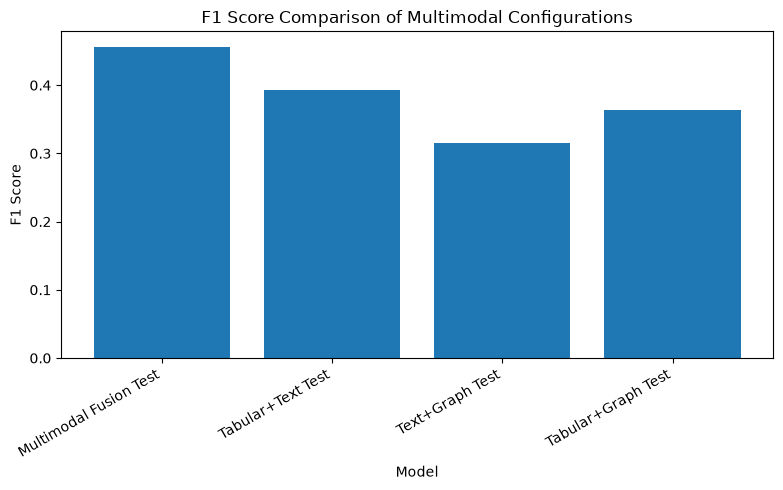

In [65]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.bar(
    test_results["Model"],
    test_results["F1"]
)


plt.ylabel("F1 Score")

plt.xlabel("Model")


plt.title(
    "F1 Score Comparison of Multimodal Configurations"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.tight_layout()


plt.show()

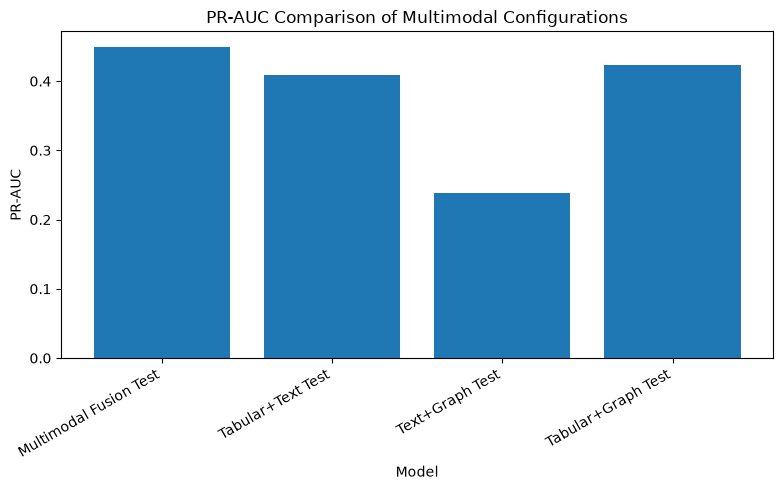

In [66]:
plt.figure(figsize=(8,5))


plt.bar(
    test_results["Model"],
    test_results["PR_AUC"]
)


plt.ylabel("PR-AUC")

plt.xlabel("Model")


plt.title(
    "PR-AUC Comparison of Multimodal Configurations"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.tight_layout()


plt.show()

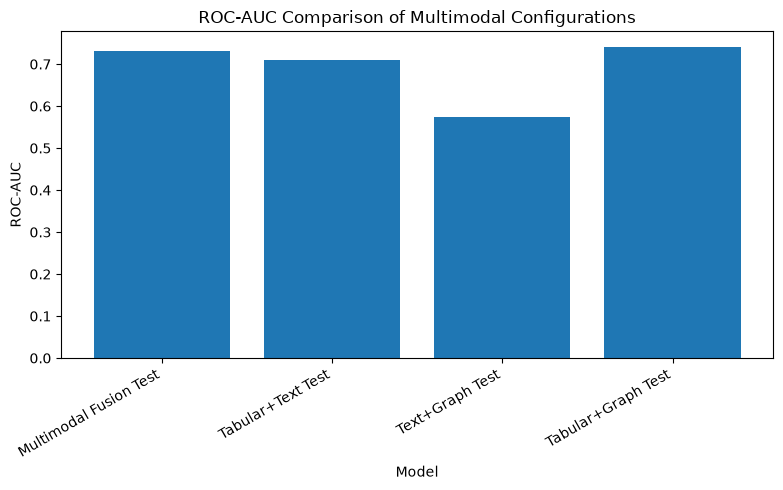

In [67]:
plt.figure(figsize=(8,5))


plt.bar(
    test_results["Model"],
    test_results["ROC_AUC"]
)


plt.ylabel("ROC-AUC")

plt.xlabel("Model")


plt.title(
    "ROC-AUC Comparison of Multimodal Configurations"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.tight_layout()


plt.show()